In [2]:
import os
import json

import geopandas as gpd
import numpy as np
import rasterio
from rasterio.mask import mask
from rasterio.plot import show
import matplotlib.pyplot as plt

In [3]:
# project paths
aoi_path = r"data/aoi.geojson"
bands_10m_path = r"data/downloads/S2A_MSIL2A_20260726T093051_N0512_R136_T34UEB_20260726T161013.SAFE/GRANULE/L2A_T34UEB_A057934_20260726T093050/IMG_DATA/R10m/"
bands_10m_clipped_path = os.path.join(bands_10m_path, "clipped")

In [4]:
# .jp2 -> JPEG 2000
# .jp2 file contains a raster: a grid of pixels where each pixel has a numerical value
# representing the measured or processed reflectance for a specific spectral band
# .jp2 files represent different spectral bands from the same Sentinel-2 observation
# spectral band is usually a single-band raster, i.e. a large matrix of pixel values

bands = [filename for filename in os.listdir(bands_10m_path) if filename.endswith(".jp2")]
bands

['T34UEB_20260726T093051_AOT_10m.jp2',
 'T34UEB_20260726T093051_B02_10m.jp2',
 'T34UEB_20260726T093051_B03_10m.jp2',
 'T34UEB_20260726T093051_B04_10m.jp2',
 'T34UEB_20260726T093051_B08_10m.jp2',
 'T34UEB_20260726T093051_TCI_10m.jp2',
 'T34UEB_20260726T093051_WVP_10m.jp2']

In [5]:
# clip rasters to the AOI
with open(aoi_path, "r") as f:
    aoi = json.load(f)

for band in bands:
    band_path = os.path.join(bands_10m_path, band)
    with rasterio.open(band_path) as src:
        # crs - coordinate reference system - układ odniesienia współrzędnych
        clipped, transform = mask(
            src,
            [aoi],
            crop=True
        )
    
        profile = src.profile.copy()
        profile.update(
            height=clipped.shape[1],
            width=clipped.shape[2],
            transform=transform
        )

        band_clipped_path = os.path.join(bands_10m_clipped_path, band)
        
        with rasterio.open(band_clipped_path, "w", **profile) as dst:
            dst.write(clipped)

In [6]:
bands_clipped = [os.path.join(bands_10m_clipped_path, filename) for filename in os.listdir(bands_10m_clipped_path) if filename.endswith(".jp2")]

In [7]:
# read all images with rasterio library
images = []

for i in bands_clipped:
    with rasterio.open(i, "r") as f:
        band = f.read(1)
        images.append(band)

In [8]:
# stack images as n dimensional array
arrImages = np.stack(images)

In [9]:
# convert to float for calculations
arrImages = arrImages.astype(float)

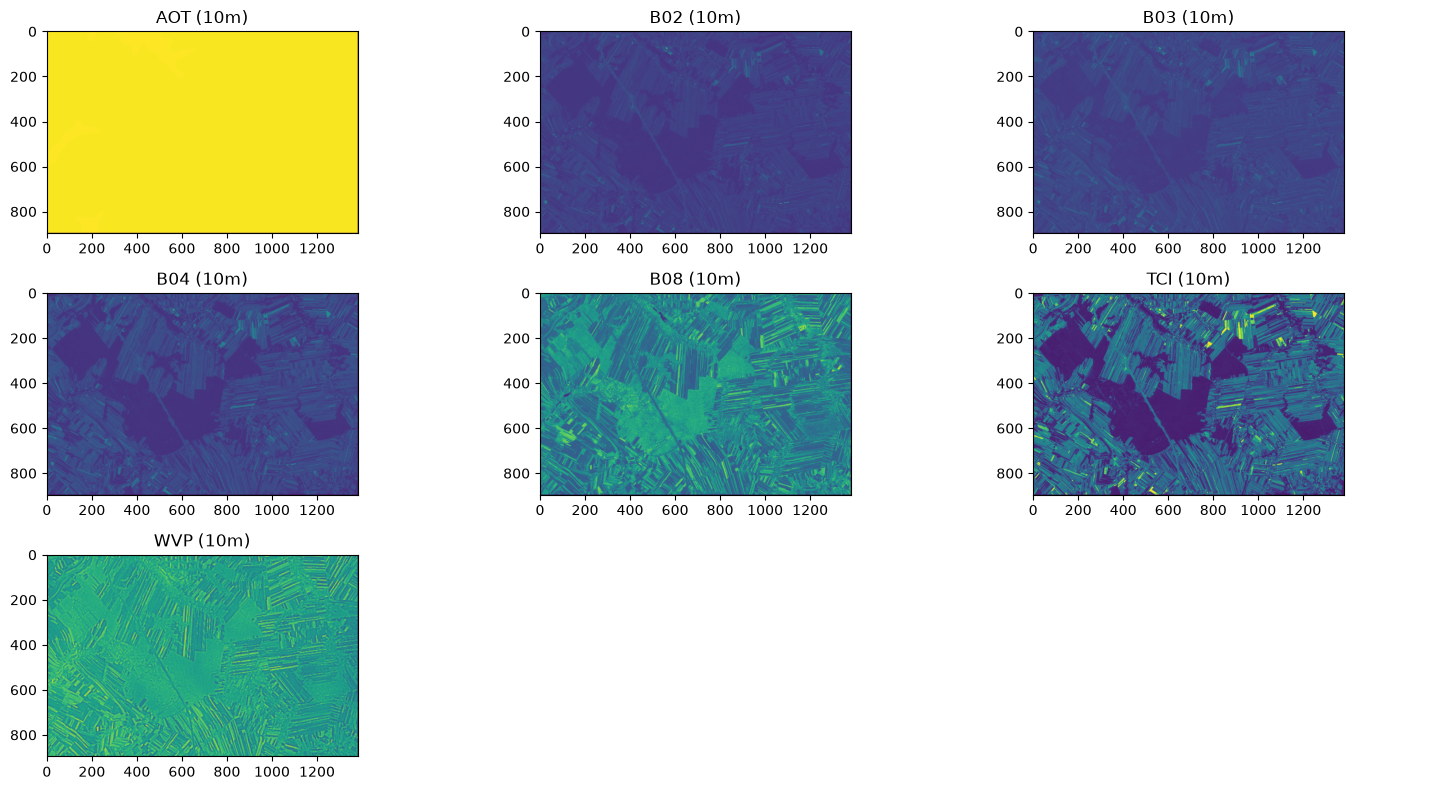

In [10]:
fig, axes = plt.subplots(3, 3, figsize=(15, 8))
axes = axes.ravel()

for i, band in enumerate(arrImages):
    axes[i].imshow(band)
    axes[i].set_title(f"{bands[i][-11:-8]} ({bands[i][-7:-4]})")
axes[7].axis("off")
axes[8].axis("off")
plt.tight_layout()

### Normalized Difference Vegetation Index (NDVI)

In [11]:
# the B04 properties
b04 = arrImages[3]
print(f"B04 shape: {b04.shape}")
print(f"B04 dtype: {b04.dtype}")
print(f"B04 min: {b04.min()}")
print(f"B04 max: {b04.max()}")

B04 shape: (896, 1382)
B04 dtype: float64
B04 min: 0.0
B04 max: 8225.0


In [12]:
# the B08 properties
b08 = arrImages[4]
print(f"B08 shape: {b08.shape}")
print(f"B04 dtype: {b04.dtype}")
print(f"B08 min: {b08.min()}")
print(f"B08 max: {b08.max()}")

B08 shape: (896, 1382)
B04 dtype: float64
B08 min: 0.0
B08 max: 8659.0


In [13]:
numerator = arrImages[4] - arrImages[3]
denominator = arrImages[4] + arrImages[3]

In [14]:
print(f"numerator min: {numerator.min()}, max: {numerator.max()}")
print(f"denominator min: {denominator.min()}, max: {denominator.max()}")

numerator min: -1708.0, max: 6740.0
denominator min: 0.0, max: 16772.0


In [15]:
ndvi = np.divide(numerator, denominator, out=np.full(arrImages[3].shape, np.nan, dtype=np.float64), where=denominator != 0)

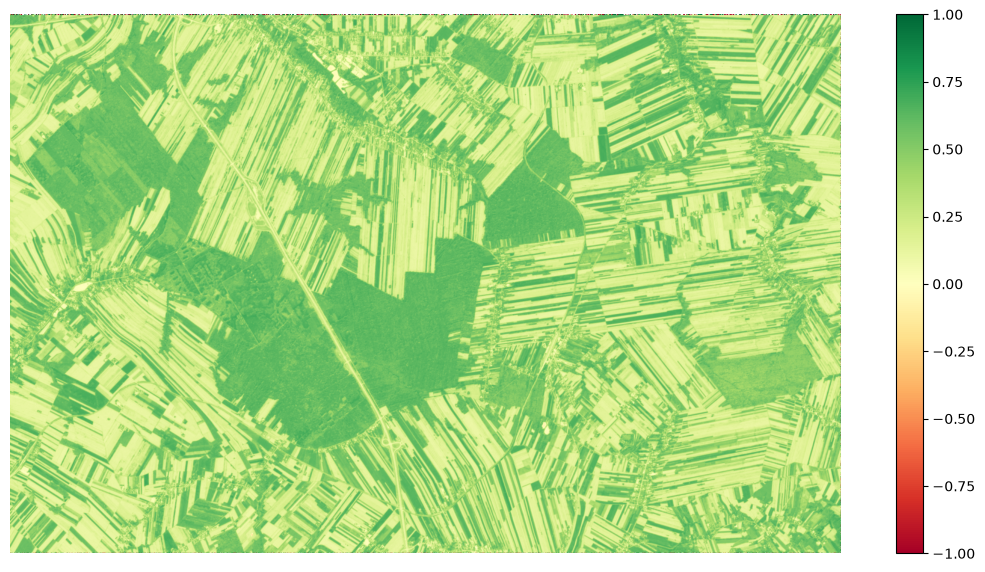

In [33]:
fig, ax = plt.subplots(figsize=(14, 7))

plt.imshow(ndvi, cmap="RdYlGn")
plt.colorbar()
ax.set_axis_off()
plt.savefig("docs/ndvi.png", )